<a href="https://colab.research.google.com/github/FlyAIBox/Context-Engineering/blob/fly/10_guides_zero_to_hero/02_expand_context.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 上下文扩展技巧：从提示到分层上下文

以实践为导向，演示如何将基础提示逐步演化为“分层、信息密度更高”的上下文结构，以提升大模型表现。重点在于：如何有策略地添加与组织上下文层，并系统化衡量它们对 token 开销与输出质量的影响。

- 由最小提示过渡到“信息丰富、结构清晰”的上下文
- 上下文分层与“组合式提示工程”的原则
- 随上下文增长对 token 使用与质量的测量与可视化
- 压缩与修剪：控制成本的关键技巧
- RAG：结合检索的上下文扩展

**建议：** 逐格运行每个单元，改动提示与参数，观察对输出与指标的影响。

**核心功能和目的可以概括为：**

- **演示不同层次的上下文构建：** 从基础提示逐步增加角色、示例、约束等信息，构建更丰富、信息密度更高的提示。
- **量化上下文的影响：** 通过测量不同提示的 Token 数量、模型响应时延和效率，来分析不同上下文策略的成本和效果。
- **探索上下文优化技巧：** 包括使用模型进行上下文压缩（总结、关键词、要点提取）和结合检索（RAG）增强提示。
- **提供实践框架：** 构建了一套 Python 函数和流程，方便用户在自己的任务中复用和测试不同的上下文策略。

总的来说，它的主要目的是帮助用户理解和掌握如何通过优化提示上下文来更好地利用大型语言模型。

### 0. 环境准备
含依赖，大模型

In [1]:
# Install necessary libraries
%pip install openai==1.61.0 matplotlib==3.10.0 tiktoken==0.11.0

In [28]:
# 大模型设置
import os
import time
from typing import Dict, List, Tuple, Any, Optional

# 导入 matplotlib 用于数据可视化，如果环境中没有则跳过
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception:
    plt = None
    HAS_MPL = False

# OpenAI API 环境配置
# 设置默认使用的 OpenAI 模型
DEFAULT_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
# 获取 OpenAI API Key
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY","sk-R2utGqjya03Bgnc77273729e7b73457e97A140D79bF3B944") # Added API Key variable
# 设置 OpenAI API 的基础 URL
OPENAI_BASE_URL = os.getenv("OPENAI_BASE_URL","https://api.apiyi.com/v1") # Added Base URL variable


from openai import OpenAI
# 初始化 OpenAI 客户端，传入 API Key 和基础 URL
client: OpenAI = OpenAI(api_key=OPENAI_API_KEY, base_url=OPENAI_BASE_URL) # Added api_key and base_url


# tiktoken 可选库，用于更精确地计算 Token 数量
# 如果 tiktoken 没有安装，则退化为粗略的 Token 估计方法
try:
    import tiktoken
    # 根据模型获取 tiktoken 编码器
    tokenizer = tiktoken.encoding_for_model(DEFAULT_MODEL)
except Exception:
    # 如果 tiktoken 导入失败，设置 tokenizer 为 None
    tokenizer = None

# 计算给定文本的 Token 数量
def count_tokens(text: str) -> int:
    if tokenizer is not None:
        # 如果 tiktoken 可用，使用 tiktoken 精确计算
        return len(tokenizer.encode(text))
    # 如果 tiktoken 不可用，使用粗略的方法估计 Token 数量（按词数 * 1.3）
    return int(len(text.split()) * 1.3)

# 测量函数的执行时间
# def measure_latency(func, *args, **kwargs) -> Tuple[Any, float]:
#     t0 = time.time() # 记录开始时间
#     res = func(*args, **kwargs) # 执行函数
#     t1 = time.time() # 记录结束时间
#     return res, (t1 - t0) # 返回函数结果和执行时间

In [29]:
# 调用大模型生成响应
def generate_response(prompt: str) -> Tuple[str, float]:
    # 客户端已初始化
    try:
        t0 = time.time() # 记录调用开始时间
        # 调用 OpenAI Chat Completion API
        resp = client.chat.completions.create(
            model=DEFAULT_MODEL, # 指定使用的模型
            messages=[{"role": "user", "content": prompt}], # 传递用户提示
            temperature=0.7, # 设置生成的多样性（0.0-1.0，越高越随机）
            max_tokens=800, # 设置响应的最大 Token 数量
        )
        latency = time.time() - t0 # 计算调用时延
        # 返回生成的文本内容和时延
        return resp.choices[0].message.content or "", latency
    except Exception as e:
        # 如果调用失败，返回错误信息和 0 时延
        return f"[OpenAI 调用失败：{e}]", 0.0

# 计算与模型交互相关的指标
def calculate_metrics(prompt: str, response: str, latency: float) -> Dict[str, float]:
    pt = count_tokens(prompt) # 计算提示的 Token 数量
    rt = count_tokens(response) # 计算响应的 Token 数量

    # 计算 Token 效率（响应 Token / 提示 Token），提示 Token 为 0 时效率为 0
    eff = (rt / pt) if pt > 0 else 0.0

    # 计算每千 Token 的时延（时延 / 提示 Token * 1000），提示 Token 为 0 时时延为 0
    latency_per_1k = (latency / pt) * 1000 if pt > 0 else 0.0

    # 返回包含各种指标的字典
    return {
        "prompt_tokens": pt,
        "response_tokens": rt,
        "token_efficiency": eff,
        "latency": latency,
        # 将每千 Token 的时延（秒），并四舍五入到两位小数
        "latency_per_1k": round(latency_per_1k, 2), # Convert to ms and round
    }

In [23]:
a=time.time()
time.sleep(3)
b=time.time()
c=round((b - a) * 1000, 2)
print(c)
print("时延：{:.2f}s".format(c))

3000.34
时延：3000.34s


### 1. 从最小提示到扩展提示

定义基础提示与多种扩展变体（角色、示例、约束、受众、综合）。


In [30]:
# 定义一个基础提示
base_prompt = "请写一段关于气候变化的说明文字。"

# 创建不同类型的扩展提示，通过添加不同的上下文信息
expanded_prompts = {
    # 基础提示，不包含任何额外上下文
    "base": base_prompt,
    # 添加“角色”上下文：指定模型扮演的角色
    "with_role": "你是一名气候系统方向的环境科学家。\n请写一段关于气候变化的说明文字。",
    # 添加“示例”上下文：提供期望输出的例子（Few-shot learning）
    "with_examples": (
        "请写一段关于气候变化的说明文字。\n\n"
        "示例 1：\n气候变化指的是温度和天气模式的长期变化。自 19 世纪以来，人类活动一直是气候变化的主要驱动因素，尤其是燃烧煤、石油、天然气等化石燃料，会产生大量热量捕获性气体。\n\n"
        "示例 2：\n全球气候变化体现在极端天气事件的频率增加、海平面上升以及野生动物种群迁移。科学共识认为人类活动是主要原因。"
    ),
    # 添加“约束”上下文：指定输出需要满足的条件或规则
    "with_constraints": (
        "请写一段关于气候变化的说明文字。\n"
        "- 至少包含一个带数字的科学事实\n"
        "- 同时提及成因与影响\n"
        "- 以‘行动倡议’结尾\n"
        "- 保持信息性且通俗易懂的语气"
    ),
    # 添加“受众”上下文：指定目标读者或用户
    "with_audience": (
        "请为刚开始接触环境科学的高中生，写一段关于气候变化的说明文字，\n"
        "尽量使用清晰解释与贴近生活的例子。"
    ),
    # 综合提示：结合了多种上下文层，构建一个信息更全面的提示
    "comprehensive": (
        "你是一名气候系统方向的环境科学家。\n\n" # 角色
        "请为刚开始接触环境科学的高中生，写一段关于气候变化的说明文字，\n" # 基础任务与受众
        "使用清晰解释与贴近生活的例子。\n\n" # 受众相关要求
        "写作指南：\n" # 约束/指南
        "- 至少包含一个带数字的科学事实\n"
        "- 同时提及成因与影响\n"
        "- 以‘行动倡议’结尾\n"
        "- 保持信息性且通俗易懂的语气\n\n"
        "语气与结构示例：\n" # 示例（提供输出的风格和结构参考）
        "海洋酸化发生在海水从大气中吸收 CO2 时，导致 pH 值下降。自工业革命以来，海洋 pH 下降了约 0.1 个单位，酸度增加约 30%。这会影响海洋生物，尤其是贝类与珊瑚。"
    ),
}

In [31]:
# 用于存储不同提示的测试结果
results = {}
# 用于存储不同提示生成的响应
responses = {}

# 遍历每种扩展提示进行测试
for name, p in expanded_prompts.items():
    print(f"测试：{name}")
    # 调用生成响应函数，并测量时延
    resp, lat = generate_response(p)
    # 存储生成的响应
    responses[name] = resp
    # 计算并存储各种指标（Token 数、效率、时延等）
    results[name] = calculate_metrics(p, resp, lat)
    # 打印测试结果摘要
    print("  提示 token：", results[name]["prompt_tokens"])
    print("  响应 token：", results[name]["response_tokens"])
    print("  时延：{:.2f}s".format(results[name]["latency"]))
    print("-" * 40)

测试：base
  提示 token： 12
  响应 token： 235
  时延：3.05s
----------------------------------------
测试：with_role
  提示 token： 24
  响应 token： 302
  时延：4.59s
----------------------------------------
测试：with_examples
  提示 token： 123
  响应 token： 199
  时延：2.04s
----------------------------------------
测试：with_constraints
  提示 token： 57
  响应 token： 259
  时延：5.29s
----------------------------------------
测试：with_audience
  提示 token： 37
  响应 token： 340
  时延：5.68s
----------------------------------------
测试：comprehensive
  提示 token： 174
  响应 token： 265
  时延：6.64s
----------------------------------------


### 2. 可视化与分析（Token/效率/时延）

运行单元格后，您会看到一个包含四个子图的图表。这个图表将我们之前测试不同提示（Prompt）得到的结果用图表的方式展示出来，帮助我们更直观地比较不同上下文扩展策略的效果。

对于大模型技术的初学者来说，理解这些指标非常重要，因为它们直接关系到使用大模型的**成本**（Token 数量）和**效率**（响应速度和生成内容的比例）。

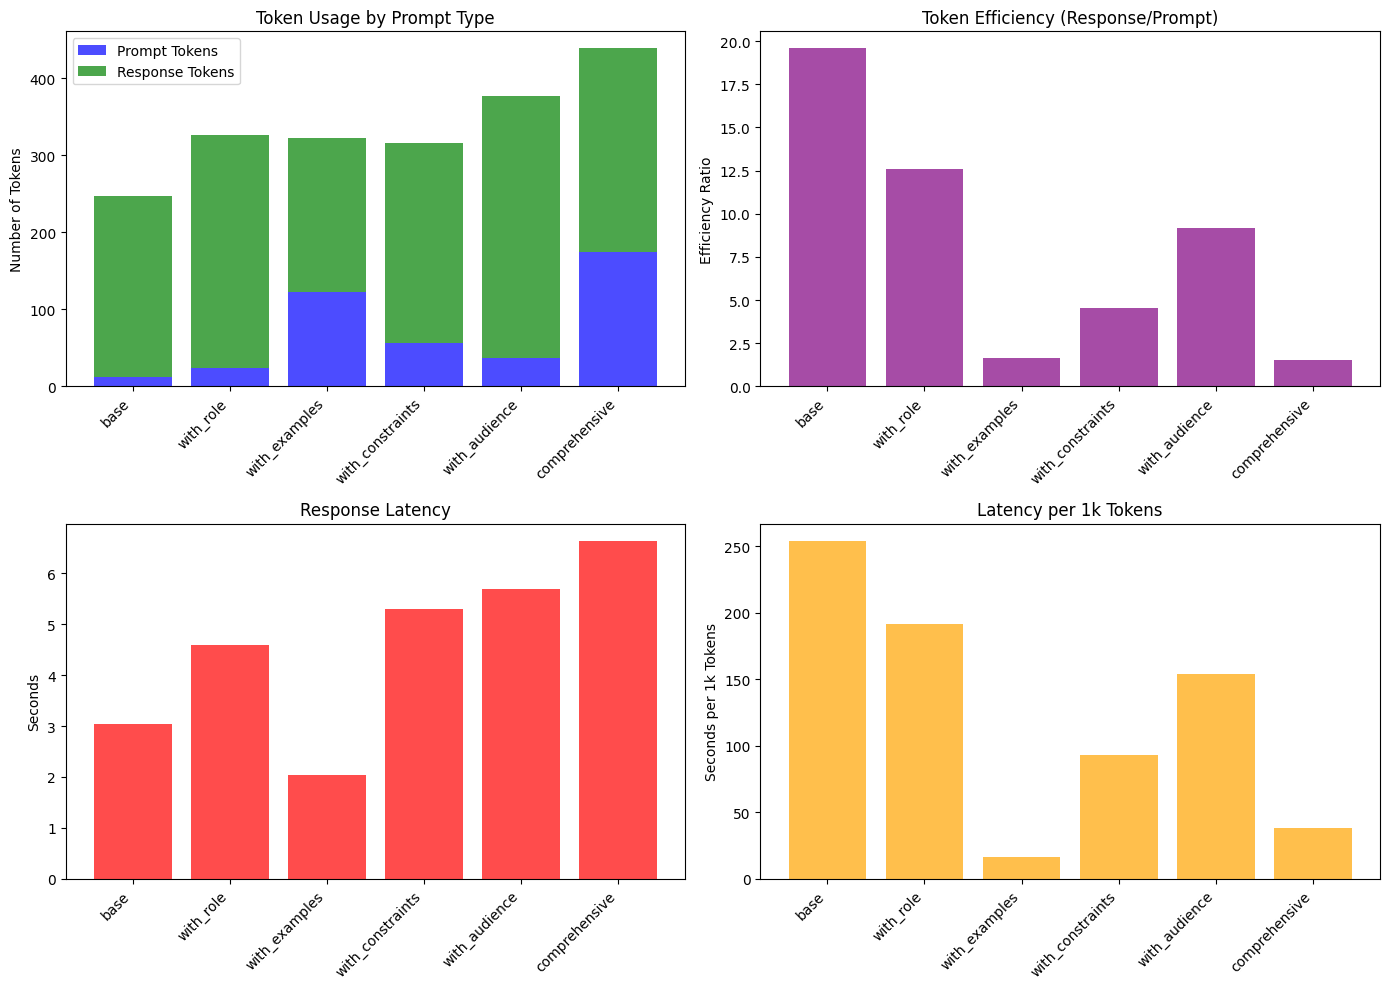

In [32]:
# 从 results 字典中提取用于绘图的数据
prompt_types = list(results.keys()) # 提示类型名称列表
prompt_tokens = [results[k]['prompt_tokens'] for k in prompt_types] # 各种提示的 Token 数量
response_tokens = [results[k]['response_tokens'] for k in prompt_types] # 各种响应的 Token 数量
latencies = [results[k]['latency'] for k in prompt_types] # 各种响应的时延

# 定义一个函数用于绘制指标的柱状图
def plot_bars():
    # 创建一个包含 2x2 子图的图表
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 第一个子图：Token Usage (提示 Token + 响应 Token)
    # Token Usage: 显示不同提示类型下，发送给模型的提示 Token 数量和模型返回的响应 Token 数量。
    # Token 是大模型处理文本的基本单位，Token 数量直接影响成本和处理时间。
    axes[0, 0].bar(prompt_types, prompt_tokens, label='Prompt Tokens', alpha=0.7, color='blue')
    axes[0, 0].bar(prompt_types, response_tokens, bottom=prompt_tokens, label='Response Tokens', alpha=0.7, color='green')
    axes[0, 0].set_title('Token Usage by Prompt Type')
    axes[0, 0].set_ylabel('Number of Tokens')
    axes[0, 0].legend()
    # 旋转 x 轴标签，避免重叠
    plt.setp(axes[0, 0].get_xticklabels(), rotation=45, ha='right')

    # 第二个子图：Token Efficiency (Response/Prompt)
    # Token Efficiency: 响应 Token 数量除以提示 Token 数量。
    # 表示模型生成响应的效率，高效率意味着用较少的提示 Token 获得了较多的响应 Token，这通常是期望的。
    token_efficiency = [results[k]['token_efficiency'] for k in prompt_types]
    axes[0, 1].bar(prompt_types, token_efficiency, color='purple', alpha=0.7)
    axes[0, 1].set_title('Token Efficiency (Response/Prompt)')
    axes[0, 1].set_ylabel('Efficiency Ratio')
    # 旋转 x 轴标签
    plt.setp(axes[0, 1].get_xticklabels(), rotation=45, ha='right')

    # 第三个子图：Response Latency
    # Response Latency: 从发送提示到接收完整响应所需的时间（以秒为单位）。
    # 反映模型的响应速度，时延越低，用户体验越好。
    latencies = [results[k]['latency'] for k in prompt_types]
    axes[1, 0].bar(prompt_types, latencies, color='red', alpha=0.7)
    axes[1, 0].set_title('Response Latency')
    axes[1, 0].set_ylabel('Seconds')
    # 旋转 x 轴标签
    plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

    # 第四个子图：Latency per 1k Tokens
    # Latency per 1k Tokens: 将总时延标准化到每处理 1000 个提示 Token 所需的时间（以毫秒为单位）。
    # 这个指标有助于比较不同提示长度下的模型性能，排除了因提示长度不同带来的绝对时延差异。
    latency_per_1k = [results[k]['latency_per_1k'] for k in prompt_types]
    axes[1, 1].bar(prompt_types, latency_per_1k, color='orange', alpha=0.7)
    axes[1, 1].set_title('Latency per 1k Tokens')
    axes[1, 1].set_ylabel('Seconds per 1k Tokens')
    # 旋转 x 轴标签
    plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

    # 自动调整子图布局，避免重叠
    plt.tight_layout()

# 检查是否安装了 matplotlib，如果安装了则绘制图表
if HAS_MPL:
    plot_bars(); # 调用绘图函数
    plt.show() # 显示图表
else:
    print('[未安装 matplotlib，跳过可视化]')

**输出图表解释：**

输出结果显示了四个柱状图，每个图都展示了不同“Prompt Type”（就是我们之前定义的各种提示，如 base、with_role、comprehensive 等）在某个指标上的表现。

1. Token Usage by Prompt Type (提示 Token + 响应 Token)
   - **图表内容：** 这个图展示了每种提示类型下，发送给模型的提示（Prompt）占用的 Token 数量（蓝色部分）以及模型返回的响应（Response）占用的 Token 数量（绿色部分）。总高度是本次交互的总 Token 数。
   - **解释：** Token 数量是使用大模型时非常关键的指标，因为它直接影响到调用的**成本**（大多数模型按 Token 收费）和模型的**处理能力**（模型有最大 Token 限制）。提示越长，发送的 Token 就越多，响应越长，返回的 Token 也越多。这个图告诉我们，不同的上下文扩展方式会显著改变提示的长度，从而影响总的 Token 消耗。例如，`comprehensive` 提示由于包含了多种信息，它的提示 Token 数量是最高的。
2. Token Efficiency (Response/Prompt)
   - **图表内容：** 这个图显示了模型响应的 Token 数量除以提示的 Token 数量的比值。
   - **解释：** 这个指标可以粗略衡量模型在给定提示下生成“有用”内容的效率。比值越高，意味着模型用相对较少的提示 Token 生成了较多的响应 Token。通常我们希望这个值高一些，但并非越高越好，关键是生成的响应要有**质量**且**相关**。基础提示 (`base`) 的效率看起来很高，但这可能是因为它提示非常简短，模型自由发挥空间大，生成的响应相对较长；而包含示例 (`with_examples`) 的提示，提示本身较长，但响应可能更聚焦，所以效率比 `base` 低。
3. Response Latency (时延)
   - **图表内容：** 这个图显示了从发送提示到接收模型完整响应所需的时间，单位是秒。
   - **解释：** 时延反映了模型的**响应速度**。对于需要快速响应的应用（比如实时聊天、自动化流程），时延是一个非常重要的指标。通常提示越长、模型越大，时延可能会越高，因为模型需要处理更多的信息。从图上看，`comprehensive` 提示的时延是最高的，这符合我们对长提示时延可能增加的预期。
4. Latency per 1k Tokens (每千 Token 的时延)
   - **图表内容：** 这个图显示的是将总时延标准化到每处理 1000 个提示 Token 所需的时间（单位是秒）。
   - **解释：** 这个指标是为了排除提示长度对时延的直接影响，更侧重于衡量模型处理单位长度输入的速度。比如，一个很长的提示时延高是正常的，但如果换算到每千 Token 的时延也很高，可能说明模型在这个任务或这种长度下处理效率不高。这个指标可以帮助我们比较不同策略在处理相同“工作量”（以 1k Token 衡量）时的相对速度。请注意，这个计算是基于**提示 Token**，所以提示 Token 为 0 或非常小的情况下，这个指标可能不太稳定或意义不大。从图上看，`with_examples` 的这个指标最低，可能是因为示例提供了清晰的结构和方向，模型处理起来更直接。

**总结：**

通过这四个图表，我们可以对比不同的上下文扩展策略如何影响 Token 使用、生成效率和响应速度。

- 增加上下文（如 `with_role`, `with_constraints`, `with_audience`, `comprehensive`）通常会**增加提示 Token 数量**。
- 提示长度增加通常会导致**总时延增加**。
- 不同类型的上下文对 Token 效率和标准化时延的影响各不相同，这取决于上下文的内容和模型如何利用这些信息。例如，提供好的 `examples` 可能会让模型更快地生成符合要求的响应，即使提示变长，标准化时延反而可能降低。

通过分析这些图表，你可以更好地理解在实际应用中，选择哪种上下文扩展方式需要在**提升输出质量**和**控制成本/时延**之间进行权衡。

### 3. 模板化：扩展上下文生成器


In [37]:
from typing import Optional

# 创建一个函数，根据传入的参数动态生成扩展上下文
def create_expanded_context(
    base_prompt: str, # 基础提示，核心任务
    role: Optional[str] = None, # 可选：指定模型扮演的角色
    examples: Optional[List[str]] = None, # 可选：提供示例
    constraints: Optional[List[str]] = None, # 可选：指定约束或要求
    audience: Optional[str] = None, # 可选：指定目标受众
    tone: Optional[str] = None, # 可选：指定输出的语气
    output_format: Optional[str] = None, # 可选：指定输出的格式
) -> str:
    parts: List[str] = [] # 用于存储构建上下文的各个部分
    if role:
        parts.append(f"你的身份：{role}。") # 添加角色信息
    parts.append(base_prompt) # 添加基础提示
    if audience:
        parts.append(f"请确保你的回答适合：{audience}。") # 添加受众信息
    if tone:
        parts.append(f"请使用 {tone} 的语气进行回答。") # 添加语气信息
    if output_format:
        parts.append(f"请将输出格式化为：{output_format}。") # 添加输出格式信息
    if constraints:
        parts.append("要求：") # 添加约束部分标题
        parts.extend([f"- {c}" for c in constraints]) # 以列表形式添加具体约束
    if examples:
        parts.append("示例：") # 添加示例部分标题
        parts.extend([f"示例 {i+1}：\n{ex}" for i, ex in enumerate(examples)]) # 以编号列表形式添加示例
    # 使用双换行符将各个部分连接起来，形成最终的扩展上下文
    return "\n\n".join(parts)

# 定义一个新的基础提示用于测试
new_base_prompt = "请解释光合作用的工作原理。"
# 使用 create_expanded_context 函数生成一个包含多种上下文层的扩展上下文
new_expanded_context = create_expanded_context(
    base_prompt=new_base_prompt, # 基础提示
    role="一位有 15 年教学经验的生物老师", # 角色
    audience="初中学生", # 受众
    tone="热情且富有教育性", # 语气
    constraints=[ # 约束列表
        "使用‘植物工厂’类比来说明",
        "提及叶绿素的作用",
        "解释其对地球生态的重要性",
        "全文不超过 200 字",
    ],
    examples=[ # 示例列表
        "光合作用就像植物体内的一家‘小工厂’……（示例内容略）",
    ],
)

# 打印生成的扩展上下文
print("模板生成的扩展上下文后的提示：\n", new_expanded_context)
print("="*100)
# 使用生成的扩展上下文调用模型生成响应
resp, lat = generate_response(new_expanded_context)
# 计算并打印响应的 Token 数量
metrics = calculate_metrics(new_expanded_context, resp, lat)
print("\n响应：\n", resp)
print("响应 token：", metrics["response_tokens"])

模板生成的扩展上下文后的提示：
 你的身份：一位有 15 年教学经验的生物老师。

请解释光合作用的工作原理。

请确保你的回答适合：初中学生。

请使用 热情且富有教育性 的语气进行回答。

要求：

- 使用‘植物工厂’类比来说明

- 提及叶绿素的作用

- 解释其对地球生态的重要性

- 全文不超过 200 字

示例：

示例 1：
光合作用就像植物体内的一家‘小工厂’……（示例内容略）

响应：
 光合作用就像植物体内的一家“小工厂”。在这家工厂里，植物利用太阳光、二氧化碳和水，制造出它们所需的食物——葡萄糖，同时释放出氧气。这个过程主要发生在植物的叶子里，叶子中有一种叫叶绿素的绿色物质，它就像工厂的“工人”，帮助吸收阳光。

想象一下，太阳是工厂的动力源，二氧化碳和水是原材料，叶绿素则是负责生产的关键角色。通过光合作用，植物不仅能存活，还能为我们提供氧气和食物，这对地球的生态系统至关重要。没有光合作用，地球上的生命将无法维持，因为所有生物都依赖植物作为食物链的基础。所以，保护植物，就是保护我们共同的家园！
响应 token： 197


### 4. 上下层优化（Layer Optimization）

对不同上下文层的组合进行系统测试，比较指标与最优配置。


In [38]:
def test_layered_contexts(base_prompt: str, context_layers: Dict[str, str]) -> Dict[str, Dict[str, Any]]:
    """
    测试不同上下文层组合的效果。

    Args:
        base_prompt: 基础提示。
        context_layers: 一个字典，键是上下文层的名称，值是对应的文本内容。

    Returns:
        一个字典，键是测试的配置名称（e.g., "base", "base+role", "all_layers"），
        值是包含该配置的提示、响应和指标的字典。
    """
    layer_results: Dict[str, Dict[str, Any]] = {} # 存储测试结果
    print("测试：base")
    # 测试基础提示
    base_resp, base_lat = generate_response(base_prompt)
    base_metrics = calculate_metrics(base_prompt, base_resp, base_lat)
    layer_results["base"] = {
        "prompt": base_prompt,
        "response": base_resp,
        **base_metrics,
    }
    print(f"  提示 token: {base_metrics['prompt_tokens']}, 响应 token: {base_metrics['response_tokens']}, 时延: {base_metrics['latency']:.2f}s, 效率: {base_metrics['token_efficiency']:.2f}")

    # 测试基础提示 + 单个上下文层
    for layer_name, layer_content in context_layers.items():
        name = f"base+{layer_name}"
        prompt = f"{base_prompt}\n\n{layer_content}" # 构建组合提示
        print(f"测试：{name}")
        resp, lat = generate_response(prompt)
        metrics = calculate_metrics(prompt, resp, lat)
        layer_results[name] = {
            "prompt": prompt,
            "response": resp,
            **metrics,
        }
        print(f"  提示 token: {metrics['prompt_tokens']}, 响应 token: {metrics['response_tokens']}, 时延: {metrics['latency']:.2f}s, 效率: {metrics['token_efficiency']:.2f}")

    # 测试基础提示 + 所有上下文层
    all_layers = "\n\n".join(context_layers.values())
    full_prompt = f"{base_prompt}\n\n{all_layers}"
    print("测试：all_layers")
    full_resp, full_lat = generate_response(full_prompt)
    full_metrics = calculate_metrics(full_prompt, full_resp, full_lat)
    layer_results["all_layers"] = {
        "prompt": full_prompt,
        "response": full_resp,
        **full_metrics,
    }
    print(f"  提示 token: {full_metrics['prompt_tokens']}, 响应 token: {full_metrics['response_tokens']}, 时延: {full_metrics['latency']:.2f}s, 效率: {full_metrics['token_efficiency']:.2f}")

    return layer_results

# 定义用于层测试的基础提示和上下文层
layer_test_prompt = "请实现一个简单的天气应用。"
context_layers = {
    "role": "你的身份：一名资深全栈工程师，兼具 UI/UX 设计经验。", # 角色层
    "requirements": "需求：\n- 展示当前温度与未来 3 天预报\n- 城市名称搜索\n- 自适应界面\n- 友好错误处理", # 需求层
    "tech_stack": "技术规格：\n- HTML / CSS / 原生 JavaScript\n- OpenWeatherMap API\n- 注释清晰、符合最佳实践", # 技术栈层
}
# 执行层测试并获取结果
layer_test_results = test_layered_contexts(layer_test_prompt, context_layers)

# 根据 Token 效率找到表现最好的配置
# 注意：这里以 token_efficiency 作为衡量标准，实际应用中可能需要结合其他指标（如质量评分）
best = max(layer_test_results.keys(), key=lambda k: layer_test_results[k]['token_efficiency'])
print("\nToken 效率最高配置：", best)

测试：base
  提示 token: 8, 响应 token: 800, 时延: 6.28s, 效率: 100.00
测试：base+role
  提示 token: 30, 响应 token: 800, 时延: 6.32s, 效率: 26.67
测试：base+requirements
  提示 token: 43, 响应 token: 800, 时延: 8.72s, 效率: 18.60
测试：base+tech_stack
  提示 token: 36, 响应 token: 800, 时延: 5.84s, 效率: 22.22
测试：all_layers
  提示 token: 94, 响应 token: 800, 时延: 6.44s, 效率: 8.51

Token 效率最高配置： base


### 5. 上下文压缩（摘要/关键词/要点）

将长上下文压缩为更短但保留关键信息的版本。


In [10]:
# 定义一个函数用于压缩上下文
def compress_context(context: str, technique: str = 'summarize') -> str:
    """
    使用不同技术压缩上下文。

    Args:
        context: 需要压缩的原始上下文。
        technique: 压缩技术，可选 'summarize', 'keywords', 'bullet'。

    Returns:
        压缩后的上下文。
    """
    # 根据指定的压缩技术构建相应的提示
    if technique == 'summarize':
        prompt = f"请精炼以下上下文，保留关键信息并减少冗余：\n\n{context}"
    elif technique == 'keywords':
        prompt = f"请提取以下上下文的关键词与关键短语（逗号分隔）：\n\n{context}"
    elif technique == 'bullet':
        prompt = f"请将以下上下文转换为结构化要点列表，覆盖核心信息：\n\n{context}"
    else:
        return context # 如果技术未知，返回原始上下文
    # 调用模型生成压缩后的内容
    resp, _ = generate_response(prompt)
    return resp

# 使用之前定义的 comprehensive 提示作为原始上下文进行压缩测试
original_context = expanded_prompts["comprehensive"]
print("原始 token：", count_tokens(original_context))

# 遍历不同的压缩技术进行测试
for tech in ['summarize', 'keywords', 'bullet']:
    out = compress_context(original_context, tech) # 执行压缩
    print(f"\n--- {tech.upper()} ---") # 打印技术名称
    print(out) # 打印压缩后的内容
    print("压缩后 token：", count_tokens(out)) # 打印压缩后的 Token 数量

原始 token： 174

--- SUMMARIZE ---
气候变化是指地球气候系统在长时间内发生的变化，主要由人类活动引起。自工业革命以来，全球气温上升了约1.2摄氏度，这主要是由于温室气体的排放，如二氧化碳和甲烷。气温上升导致极端天气事件频发，例如强烈的热浪、洪水和干旱，这对我们的生活、农作物和生态系统产生了严重影响。

为了应对气候变化，我们每个人都可以采取行动，比如减少能源消耗、使用公共交通和参与植树活动。让我们一起努力，保护地球的未来！
压缩后 token： 145

--- KEYWORDS ---
气候系统, 环境科学, 气候变化, 高中生, 科学事实, 成因, 影响, 行动倡议, 海洋酸化, CO2, pH 值, 工业革命, 酸度, 海洋生物, 贝类, 珊瑚, 信息性, 通俗易懂
压缩后 token： 73

--- BULLET ---
- **角色定位**: 气候系统方向的环境科学家
- **目标受众**: 高中生
- **主题**: 气候变化
- **内容要点**:
  - **科学事实**: 自工业革命以来，全球平均气温上升了约1.2摄氏度。
  - **成因**: 气候变化主要是由于温室气体（如二氧化碳和甲烷）大量排放，主要源于化石燃料的燃烧、森林砍伐和工业活动。
  - **影响**: 气候变化导致极端天气事件增加，例如更频繁的热浪、洪水和干旱，对生态系统和人类生活造成严重影响。
  - **生活例子**: 例如，农民可能面临作物歉收，因为气候变化使得某些地区的降水模式发生变化，影响了农作物的生长。
- **行动倡议**: 我们每个人都可以通过节约能源、使用公共交通和推广可再生能源来帮助减缓气候变化。
压缩后 token： 246


### 6. 上下文修剪：系统化删除无效层（可选）

使用模型自评来比较不同层组合下的质量分，并递归删除无效层。


In [11]:
import re

# 定义一个函数，让模型评估生成响应的质量
def evaluate_response_quality(prompt: str, response: str, criteria: List[str]) -> float:
    """
    使用模型评估响应质量并提取总体评分。

    Args:
        prompt: 用于生成响应的提示。
        response: 需要评估的响应。
        criteria: 用于评估响应的质量标准列表。

    Returns:
        总体评分 (0.0-1.0)，如果无法提取评分则返回 0.5。
    """
    # 构建用于评估的提示，包含原始提示、响应和评估标准
    crit = "\n".join([f"- {c}" for c in criteria]) # 格式化评估标准
    eval_prompt = (
        "请为以下响应基于标准打分，最后给出‘总体评分：0.0-1.0’。\n\n"
        f"提示：\n{prompt}\n\n响应：\n{response}\n\n评估标准：\n{crit}\n"
    )
    # 调用模型生成评估结果
    eval_resp, _ = generate_response(eval_prompt)
    # 使用正则表达式从评估结果中提取总体评分
    m = re.findall(r"总体评分[:：]\s*([0-9]*\.?[0-9]+)", eval_resp)
    # 如果提取到评分，返回最后一个评分（处理可能有多个评分的情况），否则返回 0.5
    return float(m[-1]) if m else 0.5

# 定义一个函数，通过递归方式修剪上下文层
def prune_context_layers(base_prompt: str, layers: Dict[str, str], criteria: List[str]) -> Tuple[str, Dict[str, Any]]:
    """
    系统性地修剪上下文层，保留对质量提升有益的层。

    Args:
        base_prompt: 基础提示。
        layers: 需要测试和修剪的上下文层字典。
        criteria: 用于评估响应质量的标准列表。

    Returns:
        最优的提示字符串和包含所有测试结果的字典。
    """
    print("--- 开始上下文层修剪测试 ---")
    results: Dict[str, Any] = {} # 存储测试结果

    # 1. 测试基础提示的质量
    print("测试：base")
    base_resp, _ = generate_response(base_prompt)
    base_quality = evaluate_response_quality(base_prompt, base_resp, criteria)
    base_tokens = count_tokens(base_prompt)
    results["base"] = {"prompt": base_prompt, "quality": base_quality, "tokens": base_tokens}
    print(f"  基础提示质量：{base_quality:.2f}, Token: {base_tokens}")

    # 如果没有上下文层需要测试，直接返回基础提示结果
    if not layers:
        print("--- 没有可修剪的上下文层 ---")
        return base_prompt, results

    # 2. 测试包含所有上下文层的提示的质量
    all_text = "\n\n".join(layers.values())
    full_prompt = f"{base_prompt}\n\n{all_text}"
    print("测试：all_layers")
    full_resp, _ = generate_response(full_prompt)
    full_quality = evaluate_response_quality(full_prompt, full_resp, criteria)
    full_tokens = count_tokens(full_prompt)
    results["all_layers"] = {"prompt": full_prompt, "quality": full_quality, "tokens": full_tokens}
    print(f"  所有层组合质量：{full_quality:.2f}, Token: {full_tokens}")

    best_quality = full_quality # 初始化最佳质量为所有层组合的质量
    best_key = "all_layers" # 初始化最佳配置为所有层组合

    # 3. 逐个移除上下文层并测试剩余组合的质量
    current_layers = layers.copy() # 复制当前上下文层字典
    removed_layer = None # 记录当前轮次移除的层

    # 尝试移除每个层，看看是否能提高或保持质量同时减少 Token
    for name in list(current_layers.keys()):
        remain = {k: v for k, v in current_layers.items() if k != name} # 移除当前层后的剩余层
        test_prompt = f"{base_prompt}\n\n" + "\n\n".join(remain.values()) # 构建测试提示
        print(f"测试：without_{name}")
        test_resp, _ = generate_response(test_prompt)
        q = evaluate_response_quality(test_prompt, test_resp, criteria) # 评估质量
        key = f"without_{name}"
        test_tokens = count_tokens(test_prompt)
        results[key] = {"prompt": test_prompt, "quality": q, "tokens": test_tokens}
        print(f"  移除 {name} 后质量：{q:.2f}, Token: {test_tokens}")

        # 判断当前组合是否是更好的选择：
        # 如果质量显著提升（例如 > 0.05），或者质量相当但 Token 减少，则更新最佳配置
        if q > best_quality + 0.05: # 质量显著提升
             best_quality, best_key = q, key
             removed_layer = name
        elif abs(q - best_quality) <= 0.05 and test_tokens < results[best_key]["tokens"]: # 质量相当但 Token 减少
             best_quality, best_key = q, key
             removed_layer = name

    print(f"本轮最佳配置：{best_key}, 质量: {best_quality:.2f}, Token: {results[best_key]['tokens']}")

    # 4. 递归调用：如果本轮移除了层并找到了更好的配置，则基于剩余层继续修剪
    if removed_layer:
        print(f"发现可移除层：{removed_layer}，继续修剪...")
        new_layers = {k: v for k, v in current_layers.items() if k != removed_layer}
        # 将当前轮次的结果合并到下一轮的 results 中
        next_prompt, next_results = prune_context_layers(base_prompt, new_layers, criteria)
        results.update(next_results) # 合并结果
        return next_prompt, results
    else:
        # 如果本轮没有移除任何层，说明已经找到局部最优解或无法进一步优化
        print("--- 修剪完成，未发现更多可移除层 ---")
        return results[best_key]["prompt"], results # 返回最佳提示和所有测试结果

# 示例用法：定义基础提示、上下文层和评估标准
prune_test_prompt = "请写一段关于人工智能伦理的短文。"
prune_context_layers_dict = {
    "role": "你的身份：一位研究人工智能伦理的学者。",
    "audience": "目标读者：对人工智能感兴趣的普通大众。",
    "constraints": "要求：\n- 提及至少两种具体的伦理挑战（如偏见、隐私）\n- 包含对未来发展的展望\n- 篇幅不超过 300 字",
    "example": "示例：\n人工智能伦理是一个复杂且日益重要的话题。随着 AI 技术飞速发展，其潜在的伦理风险也不容忽视。例如，AI 系统中的算法偏见可能导致不公平的结果……（示例内容略）",
}
prune_criteria = [
    "内容是否准确地解释了人工智能伦理挑战？",
    "是否提及了至少两种具体的伦理挑战？",
    "是否包含了对未来发展的展望？",
    "语言是否通俗易懂，适合普通大众？",
    "是否符合篇幅要求？",
    "作为学者，语气是否专业且客观？",
]

# 执行上下文层修剪过程
# pruned_prompt, prune_results = prune_context_layers(prune_test_prompt, prune_context_layers_dict, prune_criteria)
# print("\n--- 修剪结果 ---")
# print("最优提示：\n", pruned_prompt)
# print("\n各配置测试结果：")
# for key, res in prune_results.items():
#    print(f"  {key}: 质量={res['quality']:.2f}, Token={res['tokens']}")

# 由于模型自评可能引入不稳定性，这里暂时不运行修剪过程，只展示函数定义。
# 如果要运行，请取消上面三行的注释。

### 7. 结合检索（RAG）

用简单关键词匹配演示从“知识库”取回信息并拼接到提示中。


In [12]:
from typing import Dict as TDict

# 模拟一个简单的知识库，包含一些关于 pandas 的信息
kb = [
    {"title": "Pandas Introduction", "content": "Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language."},
    {"title": "Loading Data in Pandas", "content": "Pandas can read data from various file formats like CSV, Excel, SQL databases, JSON, etc. The most common functions are pd.read_csv(), pd.read_excel(), pd.read_sql()."},
    {"title": "Data Cleaning", "content": "Data cleaning involves handling missing values, duplicates, and inconsistencies. In pandas, you can use methods like dropna() to remove missing values and fillna() to fill them. Handling duplicates can be done with drop_duplicates()."},
    {"title": "Data Visualization", "content": "Pandas DataFrames have built-in plotting capabilities using matplotlib. You can create various plots directly from the DataFrame or Series."},
]

# 定义一个函数，根据用户查询从知识库中检索相关信息
def retrieve_relevant_info(query: str, knowledge_base: List[TDict[str, str]]) -> List[str]:
    """
    根据查询从知识库中检索相关信息。

    Args:
        query: 用户查询字符串。
        knowledge_base: 知识库，包含字典列表，每个字典有 'title' 和 'content' 键。

    Returns:
        一个包含检索到的相关信息内容字符串的列表，按相关度降序排列（最多返回 3 条）。
    """
    q_terms = set(query.lower().split()) # 将查询转换为小写单词集合
    hits: List[Tuple[int, str]] = [] # 存储匹配到的信息和得分
    for item in knowledge_base:
        content = item['content'].lower() # 知识库内容转小写
        title = item['title'].lower() # 知识库标题转小写
        # 计算查询词在内容或标题中出现的次数作为得分
        score = sum(1 for t in q_terms if t in content or t in title)
        if score > 0: # 只添加有匹配得分的信息
            hits.append((score, item['content']))
    hits.sort(key=lambda x: x[0], reverse=True) # 按得分降序排序
    return [h[1] for h in hits[:3]] # 返回得分最高的 3 条信息内容

# 定义一个函数，将检索到的信息添加到基础提示中构建 RAG 上下文
def create_rag_context(base_prompt: str, query: str, kb_list: List[TDict[str, str]]) -> str:
    """
    创建结合检索增强的上下文。

    Args:
        base_prompt: 基础提示。
        query: 用于检索的查询。
        kb_list: 知识库列表。

    Returns:
        结合了检索信息的扩展提示。
    """
    infos = retrieve_relevant_info(query, kb_list) # 检索相关信息
    if not infos:
        return base_prompt # 如果没有检索到信息，返回基础提示
    # 如果检索到信息，将信息添加到提示后面
    return base_prompt + "\n\n相关信息：\n\n" + "\n\n".join(infos)

# 定义一个用于 RAG 测试的提示和查询
rag_prompt = "请简要讲解如何在 pandas 中读取数据并处理缺失值。"
rag_query = "pandas loading data cleaning" # 用于检索的关键词
# 创建 RAG 上下文
rag_ctx = create_rag_context(rag_prompt, rag_query, kb)
# 打印 RAG 上下文
print("--- RAG 上下文 ---")
print(rag_ctx)
# 使用 RAG 上下文调用模型生成响应
rag_resp, _ = generate_response(rag_ctx)
# 打印 RAG 响应
print("\n--- RAG 响应 ---")
print(rag_resp)

--- RAG 上下文 ---
请简要讲解如何在 pandas 中读取数据并处理缺失值。

相关信息：

Pandas can read data from various file formats like CSV, Excel, SQL databases, JSON, etc. The most common functions are pd.read_csv(), pd.read_excel(), pd.read_sql().

Data cleaning involves handling missing values, duplicates, and inconsistencies. In pandas, you can use methods like dropna() to remove missing values and fillna() to fill them. Handling duplicates can be done with drop_duplicates().

Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language.

--- RAG 响应 ---
在Pandas中读取数据并处理缺失值的步骤如下：

### 1. 读取数据
Pandas支持从多种文件格式读取数据，最常用的函数包括：
- **CSV文件**: 使用`pd.read_csv('文件路径.csv')`
- **Excel文件**: 使用`pd.read_excel('文件路径.xlsx')`
- **SQL数据库**: 使用`pd.read_sql('SQL查询', 连接对象)`
- **JSON文件**: 使用`pd.read_json('文件路径.json')`

例如，读取CSV文件的代码如下：
```python
import pandas as pd

data = pd.read_csv('data.csv')
```

### 2. 检查缺失值
读取数据后，可以使用`isnull()`或`isna()`方法查看缺失

### 8. 结论

- 从最小提示开始，逐层扩展并量化影响
- 使用压缩与修剪降低 token 成本
- 在需要时结合检索构建高效上下文
- 模板化组织可复用提示结构

尝试在你的任务上复用此模板，并将“质量/一致性”替换为更贴合业务的评价指标。
